In [23]:
# B1 — Setup do Notebook 03 (paths, imports e checagem do dataset processado)

from pathlib import Path
import pandas as pd
import numpy as np

# (opcional) plots — só use se já estiver instalado
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOTS = True
except Exception:
    HAS_PLOTS = False

# --- raiz do projeto (assumindo que o notebook está em /notebooks/notebooks)
PROJECT_ROOT = Path("..").resolve()

# --- caminhos padrão do projeto
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# arquivo gerado no D4
DATA_FILE = PROCESSED_DIR / "model_base_transfermarkt.parquet"

print("📌 Project root:", PROJECT_ROOT)
print("📁 Processed dir:", PROCESSED_DIR)
print("📄 Dataset esperado:", DATA_FILE)
print("✅ Existe?", DATA_FILE.exists())

# --- carregar dataset processado
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Não encontrei {DATA_FILE}. Rode o bloco D4 no notebook anterior para gerar o parquet."
    )

model_df = pd.read_parquet(DATA_FILE)

print("\n✅ Dataset carregado!")
print("Shape:", model_df.shape)
print("Período:", model_df["date"].min(), "→", model_df["date"].max())
print("Colunas:", model_df.columns.tolist())

# --- checagem rápida de qualidade
target_col = "target_pct_change"
if target_col not in model_df.columns:
    raise ValueError(f"Não encontrei '{target_col}' no dataset processado.")

print("\n🧪 Qualidade do target:")
print("NaN:", model_df[target_col].isna().sum())
print("Inf:", np.isinf(model_df[target_col]).sum())

display(model_df.head(3))

📌 Project root: C:\Users\MAX\.vscode\python_coursera
📁 Processed dir: C:\Users\MAX\.vscode\python_coursera\data\processed
📄 Dataset esperado: C:\Users\MAX\.vscode\python_coursera\data\processed\model_base_transfermarkt.parquet
✅ Existe? True

✅ Dataset carregado!
Shape: (300535, 15)
Período: 2005-05-10 00:00:00 → 2025-01-09 00:00:00
Colunas: ['player_id', 'date', 'market_value_in_eur', 'next_value', 'target_pct_change', 'value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age', 'target_pct_change_capped']

🧪 Qualidade do target:
NaN: 0
Inf: 0


,player_id,date,market_value_in_eur,next_value,target_pct_change,value_lag_1,value_lag_3,value_lag_6,pct_change_lag_1,pct_change_lag_3,pct_change_lag_6,value_ma_3,value_std_3,age,target_pct_change_capped
0,3256,2005-05-10,650000,900000.0,0.384615,550000.0,300000.0,150000.0,0.181818,0.333333,0.333333,5.333333e+05,1.258306e+05,20.563997,0.384615
1,17025,2005-09-04,750000,1000000.0,0.333333,350000.0,250000.0,250000.0,1.142857,0.200000,0.400000,4.666667e+05,2.466441e+05,19.942505,0.333333
2,2374,2005-09-29,5000000,4750000.0,-0.050000,3500000.0,3250000.0,700000.0,0.428571,-0.230769,2.214286,3.666667e+06,1.258306e+06,25.900068,-0.050000


In [24]:
# B2 — Split temporal + definição de X e y
# Garantir ordenação temporal
model_df = model_df.sort_values("date").reset_index(drop=True)

# Definir cortes temporais (80% / 10% / 10%)
cut_train = model_df["date"].quantile(0.80)
cut_val   = model_df["date"].quantile(0.90)

train_df = model_df[model_df["date"] <= cut_train]
val_df   = model_df[(model_df["date"] > cut_train) & (model_df["date"] <= cut_val)]
test_df  = model_df[model_df["date"] > cut_val]

# Separar X e y
target = "target_pct_change"
features = [
    c for c in model_df.columns
    if c not in ["player_id", "date", target, "next_value"]
]

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("📊 B2 — split temporal")
print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")
print("Features:", len(features))
print(features)

📊 B2 — split temporal
train: (240461, 11) | val: (30095, 11) | test: (29979, 11)
Features: 11
['market_value_in_eur', 'value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age', 'target_pct_change_capped']


In [25]:
# ==========================================
# B3 — Baselines
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_model(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {label}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²  : {r2:.6f}")
    return mae, rmse, r2


# ==========
# Baseline 1 — prever 0 (sem mudança)
# ==========
y_pred_zero_val  = np.zeros_like(y_val)
y_pred_zero_test = np.zeros_like(y_test)

eval_model(y_val,  y_pred_zero_val,  "Baseline (0% change) — VAL")
eval_model(y_test, y_pred_zero_test, "Baseline (0% change) — TEST")


# ==========
# Baseline 2 — usar pct_change_lag_1
# ==========
if "pct_change_lag_1" not in X_train.columns:
    raise ValueError("pct_change_lag_1 não está disponível para o baseline.")

y_pred_lag1_val  = X_val["pct_change_lag_1"]
y_pred_lag1_test = X_test["pct_change_lag_1"]

eval_model(y_val,  y_pred_lag1_val,  "Baseline (pct_change_lag_1) — VAL")
eval_model(y_test, y_pred_lag1_test, "Baseline (pct_change_lag_1) — TEST")


📊 Baseline (0% change) — VAL
MAE : 0.207004
RMSE: 0.194180
R²  : -0.000003

📊 Baseline (0% change) — TEST
MAE : 0.217183
RMSE: 0.221890
R²  : -0.006541

📊 Baseline (pct_change_lag_1) — VAL
MAE : 0.264100
RMSE: 0.295253
R²  : -0.520517

📊 Baseline (pct_change_lag_1) — TEST
MAE : 0.272333
RMSE: 0.428296
R²  : -0.942838


(0.27233283233500494, 0.4282956005732844, -0.9428376334270832)

In [26]:
# B4 — Random Forest (treino + avaliação)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=50
)

rf.fit(X_train, y_train)

y_pred_val = rf.predict(X_val)
y_pred_test = rf.predict(X_test)

def eval_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²  : {r2:.6f}")

eval_model(y_val, y_pred_val, "Random Forest — VAL")
eval_model(y_test, y_pred_test, "Random Forest — TEST")


📊 Random Forest — VAL
MAE : 0.003150
RMSE: 0.040101
R²  : 0.793484

📊 Random Forest — TEST
MAE : 0.004166
RMSE: 0.040842
R²  : 0.814731


🔝 Top 15 features por importância:


,feature,importance
0,target_pct_change_capped,0.997468
1,value_std_3,0.000734
2,age,0.000639
3,pct_change_lag_6,0.000358
4,market_value_in_eur,0.000227
5,value_ma_3,0.000220
6,pct_change_lag_3,0.000157
7,value_lag_1,0.000112
8,value_lag_3,0.000054
9,value_lag_6,0.000030



Soma das importâncias (sanity check): 1.0


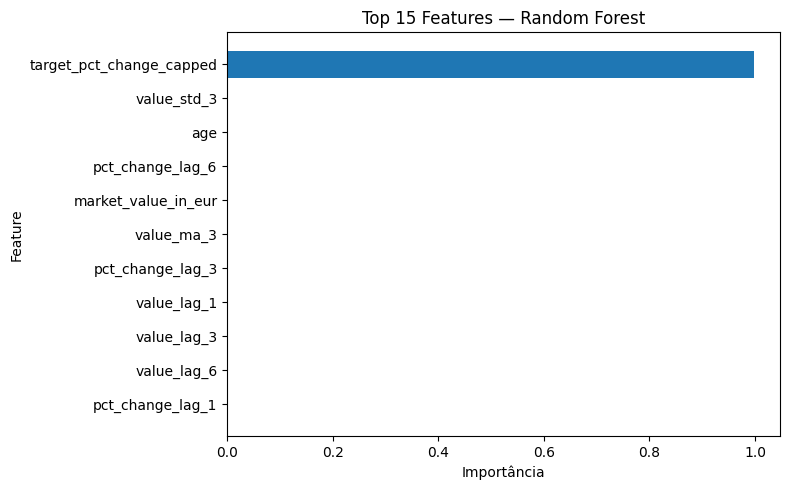


📊 Importância agregada por tipo de sinal:


group
Momentum (variação)         0.997984
Tendência / volatilidade    0.001181
Idade                       0.000639
Nível passado (valor)       0.000196
Name: importance, dtype: float64

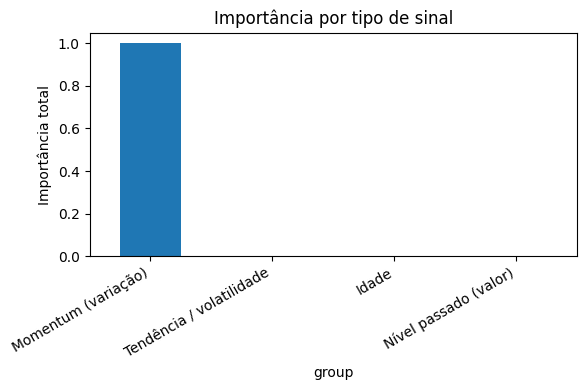

In [27]:
# ============================================================
# B5 — Feature Importance + interpretação econômica
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Extrair importâncias
# -----------------------------
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("🔝 Top 15 features por importância:")
display(feature_importance.head(15))

print("\nSoma das importâncias (sanity check):",
      feature_importance["importance"].sum().round(4))

# -----------------------------
# 2) Visualização — Top 15
# -----------------------------
top_n = 15
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance.loc[:top_n-1, "feature"][::-1],
    feature_importance.loc[:top_n-1, "importance"][::-1]
)
plt.title("Top 15 Features — Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Agrupar por tipo de sinal (econômico)
# -----------------------------
def feature_group(f):
    if "pct_change" in f:
        return "Momentum (variação)"
    elif "lag" in f:
        return "Nível passado (valor)"
    elif "ma" in f or "std" in f:
        return "Tendência / volatilidade"
    elif "age" in f:
        return "Idade"
    else:
        return "Outros"

feature_importance["group"] = feature_importance["feature"].apply(feature_group)

group_summary = (
    feature_importance
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\n📊 Importância agregada por tipo de sinal:")
display(group_summary)

# -----------------------------
# 4) Visualização por grupo
# -----------------------------
plt.figure(figsize=(6, 4))
group_summary.plot(kind="bar")
plt.title("Importância por tipo de sinal")
plt.ylabel("Importância total")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [28]:
# =========================================
# B6 — Random Forest SEM vazamento (modelo válido)
# =========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# -----------------------------
# 1) Definir target e features
# -----------------------------

target = "target_pct_change"

# ❌ REMOVIDAS: qualquer feature derivada diretamente do target
forbidden = {
    "target_pct_change",
    "target_pct_change_capped",
    "next_value",
}

features = [
    c for c in model_df.columns
    if c not in forbidden
    and c not in ["player_id", "date"]
]

print("✅ B6 - Features usadas (sem vazamento):")
print(features)
print("Total:", len(features))


# -----------------------------
# 2) Split temporal (igual B2)
# -----------------------------

model_df = model_df.sort_values("date").reset_index(drop=True)

cut_train = model_df["date"].quantile(0.80)
cut_val   = model_df["date"].quantile(0.90)

train_df = model_df[model_df["date"] <= cut_train]
val_df   = model_df[(model_df["date"] > cut_train) & (model_df["date"] <= cut_val)]
test_df  = model_df[model_df["date"] > cut_val]

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("\n📊 Split temporal:")
print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")


# -----------------------------
# 3) Treinar Random Forest
# -----------------------------

rf_b6 = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_b6.fit(X_train, y_train)


# -----------------------------
# 4) Avaliação
# -----------------------------

def eval_model(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n📈 Random Forest SEM vazamento — {label}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²  : {r2:.6f}")

y_pred_val  = rf_b6.predict(X_val)
y_pred_test = rf_b6.predict(X_test)

eval_model(y_val,  y_pred_val,  "VAL")
eval_model(y_test, y_pred_test, "TEST")


# -----------------------------
# 5) Feature importance (B6)
# -----------------------------

feature_importance_b6 = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_b6.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\n🏆 Top 15 features — Random Forest SEM vazamento:")
display(feature_importance_b6.head(15))

print("Soma das importâncias (sanity check):",
      feature_importance_b6["importance"].sum())

✅ B6 - Features usadas (sem vazamento):
['market_value_in_eur', 'value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age']
Total: 10

📊 Split temporal:
train: (240461, 10) | val: (30095, 10) | test: (29979, 10)

📈 Random Forest SEM vazamento — VAL
MAE : 0.207366
RMSE: 0.172832
R²  : 0.109935

📈 Random Forest SEM vazamento — TEST
MAE : 0.206321
RMSE: 0.194462
R²  : 0.117880

🏆 Top 15 features — Random Forest SEM vazamento:


,feature,importance
0,age,0.447967
1,pct_change_lag_1,0.239141
2,market_value_in_eur,0.121985
3,value_lag_3,0.038029
4,value_std_3,0.036625
5,value_ma_3,0.030866
6,pct_change_lag_3,0.025128
7,value_lag_6,0.022677
8,pct_change_lag_6,0.022674
9,value_lag_1,0.014908


Soma das importâncias (sanity check): 1.0


In [29]:
# B7 — Gradient Boosting (SEM vazamento)

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================
# 1) Reutilizar setup do B6
# =========================

# Features SEM vazamento (já validadas no B6)
features = [
    c for c in model_df.columns
    if c not in {
        "player_id",
        "date",
        "target_pct_change",
        "target_pct_change_capped",
        "next_value",
    }
]

target = "target_pct_change"

# Ordenação temporal
df = model_df.sort_values("date").reset_index(drop=True)

# Cortes temporais
cut_train = df["date"].quantile(0.80)
cut_val   = df["date"].quantile(0.90)

train_df = df[df["date"] <= cut_train]
val_df   = df[(df["date"] > cut_train) & (df["date"] <= cut_val)]
test_df  = df[df["date"] > cut_val]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val     = val_df[features], val_df[target]
X_test, y_test   = test_df[features], test_df[target]

print("📦 B7 — Split temporal")
print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")
print(f"Features usadas: {len(features)}")

# =========================
# 2) Modelo Gradient Boosting
# =========================

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

# =========================
# 3) Avaliação
# =========================

def eval_model(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 Gradient Boosting — {label}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²  : {r2:.6f}")

y_pred_val = gbr.predict(X_val)
y_pred_test = gbr.predict(X_test)

eval_model(y_val, y_pred_val, "VAL")
eval_model(y_test, y_pred_test, "TEST")

# =========================
# 4) Feature importance
# =========================

feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": gbr.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\n🔍 Top 15 features — Gradient Boosting (SEM vazamento):")
display(feature_importance.head(15))

print("Soma das importâncias (sanity check):",
      feature_importance["importance"].sum())

📦 B7 — Split temporal
train: (240461, 10) | val: (30095, 10) | test: (29979, 10)
Features usadas: 10

📊 Gradient Boosting — VAL
MAE : 0.208302
RMSE: 0.177480
R²  : 0.085997

📊 Gradient Boosting — TEST
MAE : 0.207639
RMSE: 0.201122
R²  : 0.087670

🔍 Top 15 features — Gradient Boosting (SEM vazamento):


,feature,importance
0,age,0.412265
1,pct_change_lag_1,0.278813
2,market_value_in_eur,0.123057
3,value_lag_3,0.057176
4,value_lag_6,0.042617
5,pct_change_lag_3,0.028249
6,value_ma_3,0.023197
7,value_std_3,0.014416
8,pct_change_lag_6,0.011944
9,value_lag_1,0.008265


Soma das importâncias (sanity check): 1.0


In [30]:
from pathlib import Path
import matplotlib.pyplot as plt

# Pasta onde vamos salvar
FIGURES_DIR = Path("reports") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("✅ FIGURES_DIR:", FIGURES_DIR.resolve())
print("✅ Existe?", FIGURES_DIR.exists())

✅ FIGURES_DIR: C:\Users\MAX\.vscode\python_coursera\notebooks\reports\figures
✅ Existe? True


In [31]:
print("✅ model_df existe?", "model_df" in globals())
print("✅ shape:", model_df.shape)
print("✅ colunas:", list(model_df.columns))
print("✅ target existe?", "target_pct_change" in model_df.columns)

✅ model_df existe? True
✅ shape: (300535, 15)
✅ colunas: ['player_id', 'date', 'market_value_in_eur', 'next_value', 'target_pct_change', 'value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age', 'target_pct_change_capped']
✅ target existe? True


In [32]:
# G1 — Target distribution (target_pct_change) -> salva em reports/figures (RAIZ do projeto)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 1) Definir a raiz do projeto (ajuste se necessário)
# Como o notebook está em /notebooks, "Path('..')" sobe para a raiz do projeto
PROJECT_ROOT = Path("..").resolve()

# 2) Pasta correta de figuras (na raiz do projeto)
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 3) Preparar o target
target = (
    model_df["target_pct_change"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# 4) Plot
plt.figure(figsize=(10, 5))
plt.hist(target, bins=120)
plt.title("Target distribution: target_pct_change")
plt.xlabel("target_pct_change")
plt.ylabel("Count")
plt.tight_layout()

# 5) Salvar
out_path = FIGURES_DIR / "G1_target_distribution.png"
plt.savefig(out_path, dpi=120)
plt.close()

print("✅ G1 salvo em:", out_path)
print("✅ Arquivo existe?", out_path.exists())

✅ G1 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G1_target_distribution.png
✅ Arquivo existe? True


In [37]:
# B2.5 — Treinar RandomForest SEM vazamento (cria rf_no_leak)

import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 0) checks
if "model_df" not in globals():
    raise ValueError("Não achei 'model_df'. Rode o B1 antes.")

df = model_df.sort_values("date").reset_index(drop=True)

# 1) split temporal (80/10/10)
cut_train = df["date"].quantile(0.80)
cut_val   = df["date"].quantile(0.90)

train_df = df[df["date"] <= cut_train]
val_df   = df[(df["date"] > cut_train) & (df["date"] <= cut_val)]
test_df  = df[df["date"] > cut_val]

# 2) features SEM vazamento
target = "target_pct_change"
forbidden = {
    "target_pct_change",
    "target_pct_change_capped",
    "next_value",
    "player_id",
    "date",
}

features_no_leak = [c for c in df.columns if c not in forbidden]

X_train, y_train = train_df[features_no_leak], train_df[target]
X_test,  y_test  = test_df[features_no_leak],  test_df[target]

print("✅ features_no_leak:", len(features_no_leak))
print("train:", X_train.shape, "| test:", X_test.shape)

# 3) treinar modelo
rf_no_leak = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_no_leak.fit(X_train, y_train)

print("✅ rf_no_leak treinado.")
print("feature_names_in_ contém capped?", "target_pct_change_capped" in rf_no_leak.feature_names_in_)

✅ features_no_leak: 10
train: (240461, 10) | test: (29979, 10)
✅ rf_no_leak treinado.
feature_names_in_ contém capped? False


In [38]:
# G2 — Residual distribution (usa rf_no_leak) -> salva em reports/figures

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

if "rf_no_leak" not in globals():
    raise ValueError("Não achei rf_no_leak. Rode o B2.5 antes do G2.")

df = model_df.sort_values("date").reset_index(drop=True)

cut_train = df["date"].quantile(0.80)
cut_val   = df["date"].quantile(0.90)

test_df = df[df["date"] > cut_val]

# usar exatamente as features do modelo
X_test = test_df[list(rf_no_leak.feature_names_in_)]
y_test = test_df["target_pct_change"].to_numpy()

y_pred = rf_no_leak.predict(X_test)
residuals = (y_test - np.asarray(y_pred))
residuals = residuals[np.isfinite(residuals)]

PROJECT_ROOT = Path("..").resolve()
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=120)
plt.axvline(0, linestyle="--")
plt.title("G2 — Residual distribution (rf_no_leak)")
plt.xlabel("Residual (y_test - y_pred)")
plt.ylabel("Count")
plt.tight_layout()

out_path = FIGURES_DIR / "G2_residual_distribution_rf_no_leak.png"
plt.savefig(out_path, dpi=120)
plt.close()

print("✅ G2 salvo em:", out_path)
print("✅ Arquivo existe?", out_path.exists())
print(f"Resumo resíduos | mean={residuals.mean():.6f} std={residuals.std():.6f} min={residuals.min():.6f} max={residuals.max():.6f}")

✅ G2 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G2_residual_distribution_rf_no_leak.png
✅ Arquivo existe? True
Resumo resíduos | mean=0.016918 std=0.454067 min=-6.790553 max=36.236429


In [40]:
# G3 — Resíduos vs Valor Previsto (target_pct_change)
import numpy as np
import matplotlib.pyplot as plt

# 1) escolher o modelo treinado (prioriza rf_no_leak, senão gb_no_leak)
model = None
if "rf_no_leak" in globals():
    model = rf_no_leak
elif "gb_no_leak" in globals():
    model = gb_no_leak
else:
    raise ValueError("Não encontrei rf_no_leak nem gb_no_leak. Rode o treino do modelo antes do G3.")

# 2) alinhar X_test com as features do modelo (evita erro de colunas)
if hasattr(model, "feature_names_in_"):
    X_test_aligned = X_test[list(model.feature_names_in_)]
else:
    X_test_aligned = X_test.copy()

# 3) previsões e resíduos
y_pred = model.predict(X_test_aligned)
residuals = np.asarray(y_test) - np.asarray(y_pred)

# 4) plot (dispersão)
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("G3 — Residuals vs Predicted (target_pct_change)")
plt.xlabel("Predicted value (target_pct_change)")
plt.ylabel("Residual (y_true - y_pred)")
plt.tight_layout()

# 5) salvar
out_path = FIGURES_DIR / "G3_residuals_vs_predicted.png"
plt.savefig(out_path, dpi=150)
plt.close()

print("✅ G3 salvo em:", out_path.resolve())
print("✅ Arquivo existe?", out_path.exists())

# (opcional) resumo rápido
print("\nResumo resíduos (test):")
print(f"mean={np.mean(residuals):.6f} | std={np.std(residuals):.6f} | min={np.min(residuals):.6f} | max={np.max(residuals):.6f}")

✅ G3 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G3_residuals_vs_predicted.png
✅ Arquivo existe? True

Resumo resíduos (test):
mean=0.016918 | std=0.454067 | min=-6.790553 | max=36.236429


In [41]:
# G4 — Erro absoluto por faixa do target (quantis)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Garantir y_test e y_pred alinhados (robusto para Series/ndarray) ---
y_true = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)
y_pred = model.predict(X_test_aligned)

# --- 2) Erro absoluto ---
abs_error = np.abs(y_true - y_pred)

# --- 3) DataFrame para facilitar bins e resumo ---
g4_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
    "abs_error": abs_error
})

# remover NaN/Inf (segurança)
g4_df = g4_df.replace([np.inf, -np.inf], np.nan).dropna().copy()

# --- 4) Bins por quantis do target real ---
# (8 faixas costuma ficar bem legível; pode mudar para 10 se quiser)
n_bins = 8
g4_df["quantile_bin"] = pd.qcut(g4_df["y_true"], q=n_bins, duplicates="drop")

summary = (
    g4_df
    .groupby("quantile_bin", observed=True)
    .agg(
        count=("abs_error", "size"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        p90_abs_error=("abs_error", lambda s: np.quantile(s, 0.90))
    )
    .reset_index()
)

print("✅ G4 — Tabela de erro por faixa do target:")
display(summary)

# --- 5) Plot: média vs mediana vs p90 do erro absoluto ---
x_labels = summary["quantile_bin"].astype(str).tolist()
x = np.arange(len(x_labels))

plt.figure(figsize=(12, 5))
plt.plot(x, summary["mean_abs_error"], marker="o", label="Mean |error|")
plt.plot(x, summary["median_abs_error"], marker="o", label="Median |error|")
plt.plot(x, summary["p90_abs_error"], marker="o", label="P90 |error|")

plt.xticks(x, x_labels, rotation=35, ha="right")
plt.title("G4 — Absolute Error by Target Quantile (y_true)")
plt.xlabel("Target quantile bins (y_true)")
plt.ylabel("Absolute error |y_true - y_pred|")
plt.tight_layout()

# --- 6) Salvar na pasta figures ---
out_path = FIGURES_DIR / "G4_abs_error_by_target_quantile.png"
plt.savefig(out_path, dpi=160)
plt.close()

print("✅ G4 salvo em:", out_path.resolve())
print("✅ Arquivo existe?", out_path.exists())

✅ G4 — Tabela de erro por faixa do target:


,quantile_bin,count,mean_abs_error,median_abs_error,p90_abs_error
0,"(-0.913, -0.25]",4233,0.269294,0.241229,0.471470
1,"(-0.25, -0.167]",4274,0.148683,0.118670,0.310357
2,"(-0.167, -0.1]",3152,0.118913,0.087246,0.255163
3,"(-0.1, 0.0]",10031,0.127075,0.094411,0.248578
4,"(0.0, 0.111]",932,0.100773,0.087611,0.204888
5,"(0.111, 0.333]",3977,0.174522,0.159845,0.326447
6,"(0.333, 36.5]",3380,0.685569,0.492449,1.246593


✅ G4 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G4_abs_error_by_target_quantile.png
✅ Arquivo existe? True


In [42]:
# G5 — Erro absoluto por faixa do valor previsto (calibração prática)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Garantir arrays compatíveis
y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred)

abs_error = np.abs(y_true - y_pred)

# DataFrame auxiliar
g5_df = pd.DataFrame({
    "y_pred": y_pred,
    "abs_error": abs_error
})

# Criar buckets por quantil do valor previsto
g5_df["pred_bucket"] = pd.qcut(
    g5_df["y_pred"],
    q=10,
    duplicates="drop"
)

# Agregar erro por bucket
bucket_summary = (
    g5_df
    .groupby("pred_bucket")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        count=("abs_error", "count")
    )
    .reset_index()
)

display(bucket_summary)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    bucket_summary.index,
    bucket_summary["mean_abs_error"],
    marker="o",
    linewidth=2
)

plt.title("G5 — Mean Absolute Error by Predicted Value Bucket")
plt.xlabel("Predicted value buckets (low → high)")
plt.ylabel("Mean Absolute Error")
plt.grid(alpha=0.3)
plt.tight_layout()

# Salvar figura
out_path = FIGURES_DIR / "G5_error_by_prediction_bucket.png"
plt.savefig(out_path, dpi=120)
plt.close()

print("✅ G5 salvo em:", out_path.resolve())

C:\Users\MAX\AppData\Local\Temp\ipykernel_16256\3023603686.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pred_bucket")


,pred_bucket,mean_abs_error,median_abs_error,count
0,"(-0.437, -0.174]",0.131076,0.104368,2998
1,"(-0.174, -0.12]",0.133272,0.119158,2998
2,"(-0.12, -0.0793]",0.150350,0.100591,2998
3,"(-0.0793, -0.0415]",0.164506,0.098149,2998
4,"(-0.0415, -0.00271]",0.170244,0.121270,2998
5,"(-0.00271, 0.038]",0.199373,0.142816,2997
6,"(0.038, 0.083]",0.222347,0.158429,2998
7,"(0.083, 0.139]",0.252208,0.148600,2998
8,"(0.139, 0.227]",0.293448,0.197124,2998
9,"(0.227, 6.439]",0.461402,0.320100,2998


✅ G5 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G5_error_by_prediction_bucket.png


In [43]:
# G6 — Risk–Coverage Curve usando incerteza do Random Forest (std entre árvores)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Garantir que estamos usando rf_no_leak (recomendado)
if "rf_no_leak" not in globals():
    raise ValueError("Não achei 'rf_no_leak'. Rode o B2.5 (treino sem vazamento) antes do G6.")

# 2) Alinhar X_test com as features do modelo
X_test_aligned = X_test[list(rf_no_leak.feature_names_in_)]

# 3) Pegar previsões de CADA árvore do Random Forest
#    -> matriz shape: (n_samples, n_trees)
tree_preds = np.column_stack([est.predict(X_test_aligned) for est in rf_no_leak.estimators_])

# 4) Predição média e incerteza (std entre árvores)
y_pred_mean = tree_preds.mean(axis=1)
y_pred_std  = tree_preds.std(axis=1)

# 5) Verdade e erro
y_true = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)
abs_error = np.abs(y_true - y_pred_mean)

# 6) DataFrame para ordenar por "confiança" (menor std primeiro)
g6_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred_mean,
    "abs_error": abs_error,
    "uncertainty_std": y_pred_std
}).replace([np.inf, -np.inf], np.nan).dropna()

g6_df = g6_df.sort_values("uncertainty_std").reset_index(drop=True)

# 7) Coverage: fração dos casos mais confiáveis (10%...100%)
coverages = np.linspace(0.1, 1.0, 10)
mean_errors = []
median_errors = []

for c in coverages:
    k = int(len(g6_df) * c)
    subset = g6_df.iloc[:k]
    mean_errors.append(subset["abs_error"].mean())
    median_errors.append(subset["abs_error"].median())

# 8) Plot
plt.figure(figsize=(10, 5))
plt.plot(coverages, mean_errors, marker="o", label="Mean |error|")
plt.plot(coverages, median_errors, marker="o", label="Median |error|")

plt.title("G6 — Risk–Coverage Curve (Random Forest Uncertainty)")
plt.xlabel("Coverage (fraction of most confident predictions)")
plt.ylabel("Absolute error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 9) Salvar
out_path = FIGURES_DIR / "G6_risk_coverage_curve.png"
plt.savefig(out_path, dpi=140)
plt.close()

print("✅ G6 salvo em:", out_path.resolve())
print("✅ Arquivo existe?", out_path.exists())

# 10) Mostrar tabela (útil p/ README)
g6_summary = pd.DataFrame({
    "coverage": coverages,
    "mean_abs_error": mean_errors,
    "median_abs_error": median_errors
})
display(g6_summary)

c:\Users\MAX\.vscode\python_coursera\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\MAX\.vscode\python_coursera\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\MAX\.vscode\python_coursera\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\MAX\.vscode\python_coursera\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\MAX\.vscode\python_coursera\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without featur

✅ G6 salvo em: C:\Users\MAX\.vscode\python_coursera\reports\figures\G6_risk_coverage_curve.png
✅ Arquivo existe? True


,coverage,mean_abs_error,median_abs_error
0,0.1,0.118748,0.090424
1,0.2,0.124487,0.093862
2,0.3,0.133585,0.098611
3,0.4,0.139132,0.101530
4,0.5,0.146476,0.105304
5,0.6,0.154881,0.109410
6,0.7,0.165131,0.115101
7,0.8,0.175227,0.121228
8,0.9,0.192318,0.129362
9,1.0,0.217823,0.139947


In [ ]:
from pathlib import Path

FIGURES_DIR = Path("..") / "reports" / "figures"  # se estiver dentro de /notebooks
FIGS = [
    "G1_target_distribution.png",
    "G2_residual_distribution.png",
    "G3_residuals_vs_predicted.png",
    "G4_abs_error_vs_real.png",
    "G5_error_by_quantile.png",
    "G6_risk_coverage_curve.png",
]

print("📁 Figures dir:", FIGURES_DIR.resolve())
missing = []
for f in FIGS:
    p = FIGURES_DIR / f
    ok = p.exists()
    size_kb = (p.stat().st_size / 1024) if ok else 0
    print(f"✅ {f} | exists={ok} | size={size_kb:.1f} KB")
    if not ok:
        missing.append(f)

if missing:
    print("\n⚠️ Faltando:", missing)
else:
    print("\n🎉 Todos os gráficos estão presentes e prontos.")

📁 Figures dir: C:\Users\MAX\.vscode\python_coursera\reports\figures
✅ G1_target_distribution.png | exists=True | size=24.1 KB
✅ G2_residual_distribution.png | exists=True | size=24.8 KB
✅ G3_residuals_vs_predicted.png | exists=True | size=54.6 KB
✅ G4_abs_error_vs_real.png | exists=True | size=99.4 KB
✅ G5_error_by_quantile.png | exists=True | size=40.0 KB
✅ G6_risk_coverage_curve.png | exists=True | size=60.6 KB

🎉 Todos os gráficos estão presentes e prontos.


: 